In [3]:
import gymnasium as gym
import numpy as np

env = gym.make("CarRacing-v3", render_mode="rgb_array")
observation, info = env.reset()

# Access the internal track points
# track is a list of tuples: (angle, x, y)
track_points = np.array([(p[2], p[3]) for p in env.unwrapped.track])

# Close the loop by appending the first point to the end
track_points = np.vstack([track_points, track_points[0]])

In [4]:
from scipy.optimize import minimize

def compute_optimal_line(track_points, width=6.0):
    n = len(track_points)
    
    # 1. Calculate tangent and normal vectors
    tangents = np.roll(track_points, -1, axis=0) - np.roll(track_points, 1, axis=0)
    normals = np.array([-tangents[:, 1], tangents[:, 0]]).T
    normals /= np.linalg.norm(normals, axis=1)[:, np.newaxis]

    # 2. Objective function: Minimize sum of squared second derivatives
    def objective(alpha):
        # Reconstruct path based on offsets alpha
        path = track_points + (alpha[:, np.newaxis] * normals * width)
        
        # Calculate second derivatives (acceleration/curvature)
        # Using central differences
        dx = np.gradient(path[:, 0])
        dy = np.gradient(path[:, 1])
        ddx = np.gradient(dx)
        ddy = np.gradient(dy)
        
        return np.sum(ddx**2 + ddy**2)

    # 3. Constraints: Alpha must be between -0.9 and 0.9 (stay on track)
    bounds = [(-0.9, 0.9) for _ in range(n)]
    
    # 4. Initial guess: The centerline (alpha = 0)
    init_alpha = np.zeros(n)
    
    res = minimize(objective, init_alpha, bounds=bounds, method='L-BFGS-B')
    
    optimal_path = track_points + (res.x[:, np.newaxis] * normals * width)
    return optimal_path

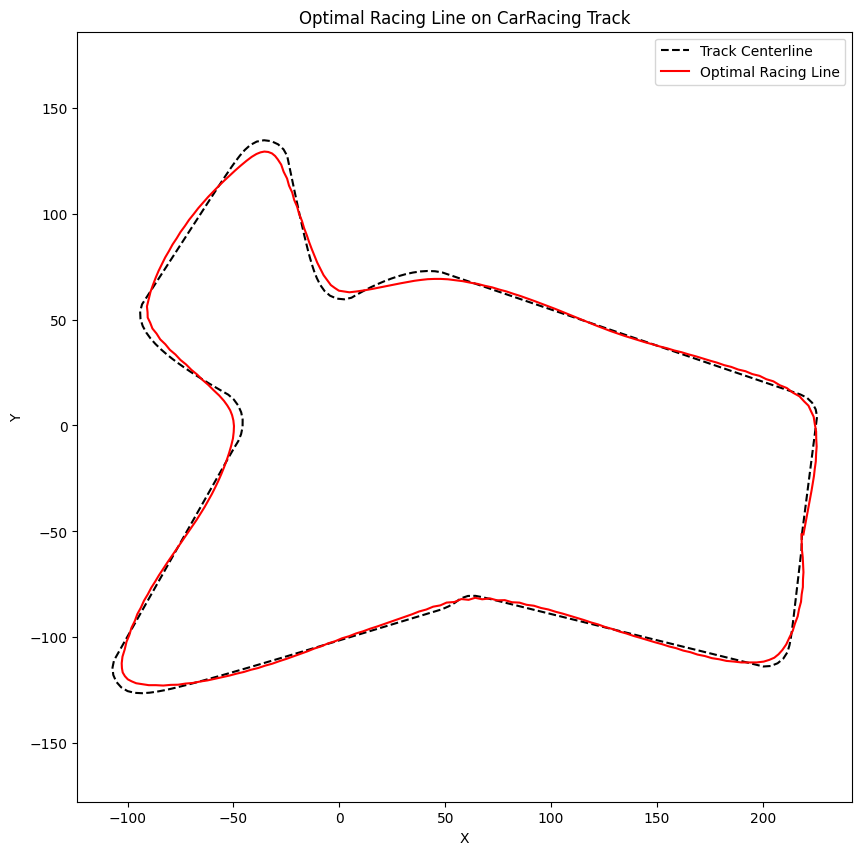

In [5]:
import matplotlib.pyplot as plt

optimal_path = compute_optimal_line(track_points)

plt.figure(figsize=(10, 10))
plt.plot(track_points[:, 0], track_points[:, 1], 'k--', label='Track Centerline')
plt.plot(optimal_path[:, 0], optimal_path[:, 1], 'r-', label='Optimal Racing Line')
plt.legend()
plt.title('Optimal Racing Line on CarRacing Track')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.show()